##Setup

In [1]:
!pip install gymnasium shimmy ale-py
!pip install autorom
!AutoROM -y

AutoROM will download the Atari 2600 ROMs.
They will be installed to:
	/usr/local/lib/python3.12/dist-packages/AutoROM/roms

Existing ROMs will be overwritten.
Installed /usr/local/lib/python3.12/dist-packages/AutoROM/roms/adventure.bin
Installed /usr/local/lib/python3.12/dist-packages/AutoROM/roms/air_raid.bin
Installed /usr/local/lib/python3.12/dist-packages/AutoROM/roms/alien.bin
Installed /usr/local/lib/python3.12/dist-packages/AutoROM/roms/amidar.bin
Installed /usr/local/lib/python3.12/dist-packages/AutoROM/roms/assault.bin
Installed /usr/local/lib/python3.12/dist-packages/AutoROM/roms/asterix.bin
Installed /usr/local/lib/python3.12/dist-packages/AutoROM/roms/asteroids.bin
Installed /usr/local/lib/python3.12/dist-packages/AutoROM/roms/atlantis.bin
Installed /usr/local/lib/python3.12/dist-packages/AutoROM/roms/atlantis2.bin
Installed /usr/local/lib/python3.12/dist-packages/AutoROM/roms/backgammon.bin
Installed /usr/local/lib/python3.12/dist-packages/AutoROM/roms/bank_heist.bin
Inst

In [7]:
"""
live_plot.py — drop-in live metrics dashboard for Go-Explore notebooks.

Usage
-----
from live_plot import MetricsDashboard

dashboard = MetricsDashboard(metrics=['max_reward', 'cells', 'loss', 'entropy'])

# inside your training loop, replace print(...) with:
dashboard.update(
    iteration   = iterations,
    frames      = frames,
    max_reward  = highscore,
    cells       = len(archive),
    loss        = loss,
    entropy     = entropy,   # omit kwargs that don't apply to your algorithm
)
"""

import matplotlib
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.ticker import MaxNLocator
from IPython import display as ipydisplay
from collections import defaultdict
import numpy as np

# ── Aesthetic config ──────────────────────────────────────────────────────────
BG       = '#0d1117'
PANEL_BG = '#161b22'
GRID_COL = '#21262d'
TEXT     = '#e6edf3'
MUTED    = '#8b949e'
BORDER   = '#30363d'

PALETTE = [
    '#58a6ff',   # blue       — max_reward
    '#3fb950',   # green      — cells
    '#f78166',   # red-orange — loss
    '#d2a8ff',   # lavender   — entropy
    '#ffa657',   # amber      — actor_loss
    '#79c0ff',   # light blue — critic_loss
]

# Human-readable labels for known metric keys
LABELS = {
    'max_reward'  : 'Max Reward',
    'cells'       : 'Archive Cells',
    'loss'        : 'Loss',
    'entropy'     : 'Entropy',
    'actor_loss'  : 'Actor Loss',
    'critic_loss' : 'Critic Loss',
    'epsilon'     : 'Epsilon',
    'frames'      : 'Frames',
}


class MetricsDashboard:
    """
    Live-updating matplotlib dashboard for Jupyter notebooks.

    Parameters
    ----------
    metrics : list[str]
        Names of the metrics to plot, e.g. ['max_reward', 'cells', 'loss'].
        Each gets its own subplot panel.
    title : str
        Dashboard title shown at the top.
    update_every : int
        Redraw the figure every N calls to .update(). Higher = faster training,
        less smooth graph. Default 1 redraws every iteration.
    window : int | None
        If set, only the last `window` iterations are shown (rolling view).
        None shows the full history.
    """

    def __init__(
        self,
        metrics       : list,
        title         : str  = 'Go-Explore Training',
        update_every  : int  = 1,
        window        : int | None = None,
    ):
        if not metrics:
            raise ValueError('Provide at least one metric name.')

        self.metrics      = metrics
        self.title        = title
        self.update_every = update_every
        self.window       = window
        self._call_count  = 0

        # History stores: iteration index + one list per metric
        self._iters : list[int]            = []
        self._data  : dict[str, list[float]] = defaultdict(list)

        matplotlib.rcParams.update({
            'font.family'      : 'monospace',
            'axes.facecolor'   : PANEL_BG,
            'figure.facecolor' : BG,
            'text.color'       : TEXT,
            'axes.labelcolor'  : MUTED,
            'xtick.color'      : MUTED,
            'ytick.color'      : MUTED,
            'axes.edgecolor'   : BORDER,
            'axes.grid'        : True,
            'grid.color'       : GRID_COL,
            'grid.linewidth'   : 0.6,
            'axes.spines.top'  : False,
            'axes.spines.right': False,
        })

        n    = len(metrics)
        cols = min(n, 2)
        rows = (n + 1) // 2

        self._fig = plt.figure(
            figsize    = (7 * cols, 3.2 * rows + 0.8),
            facecolor  = BG,
        )

        # Title row + metric panels
        outer = gridspec.GridSpec(
            2, 1,
            figure       = self._fig,
            height_ratios= [0.18, 1],
            hspace       = 0.05,
        )
        inner = gridspec.GridSpecFromSubplotSpec(
            rows, cols,
            subplot_spec = outer[1],
            hspace       = 0.55,
            wspace       = 0.35,
        )

        # Header panel (text only)
        self._header_ax = self._fig.add_subplot(outer[0])
        self._header_ax.axis('off')
        self._title_text = self._header_ax.text(
            0.5, 0.45, title,
            transform = self._header_ax.transAxes,
            ha='center', va='center',
            fontsize=15, fontweight='bold',
            color=TEXT, fontfamily='monospace',
        )
        self._subtitle_text = self._header_ax.text(
            0.5, -0.25, '',
            transform = self._header_ax.transAxes,
            ha='center', va='center',
            fontsize=9, color=MUTED, fontfamily='monospace',
        )

        # One subplot per metric
        self._axes = []
        self._lines = []
        for idx, metric in enumerate(metrics):
            row, col = divmod(idx, cols)
            ax = self._fig.add_subplot(inner[row, col])
            ax.set_title(
                LABELS.get(metric, metric),
                fontsize=10, color=MUTED,
                pad=6, loc='left',
            )
            ax.xaxis.set_major_locator(MaxNLocator(integer=True, nbins=5))
            ax.yaxis.set_major_locator(MaxNLocator(nbins=5))
            ax.tick_params(labelsize=7)

            color = PALETTE[idx % len(PALETTE)]
            (line,) = ax.plot([], [], color=color, linewidth=1.6, antialiased=True)

            # Subtle fill under the curve
            ax.fill_between([], [], color=color, alpha=0.08)

            self._axes.append(ax)
            self._lines.append(line)

        # Hide any unused subplot slots
        for idx in range(len(metrics), rows * cols):
            row, col = divmod(idx, cols)
            self._fig.add_subplot(inner[row, col]).set_visible(False)

        plt.close(self._fig)   # Don't show yet; we control display manually

    # ─────────────────────────────────────────────────────────────────────────
    def update(self, iteration: int, frames: int = 0, **metric_values):
        """
        Record one data point and optionally redraw.

        Parameters
        ----------
        iteration : int
            Current training iteration (x-axis).
        frames : int
            Total environment frames so far (shown in subtitle).
            If 'frames' is also listed in the `metrics` list passed to
            __init__, it will be plotted as a panel too — the named parameter
            and the plottable metric are the same value.
        **metric_values
            Keyword arguments matching the `metrics` list passed to __init__.
            Unknown keys are silently ignored.
        """
        # FIX: 'frames' is an explicit named parameter used for the subtitle,
        # so passing frames=N never reaches **metric_values — it gets consumed
        # by the signature before ** sees it. If the user listed 'frames' as a
        # metric to plot, inject it back into the lookup dict here.
        if 'frames' in self.metrics:
            metric_values = {**metric_values, 'frames': frames}

        self._iters.append(iteration)
        for metric in self.metrics:
            value = metric_values.get(metric, float('nan'))
            self._data[metric].append(float(value))

        self._call_count += 1
        if self._call_count % self.update_every == 0:
            self._redraw(frames)

    # ─────────────────────────────────────────────────────────────────────────
    def _redraw(self, frames: int):
        iters = np.array(self._iters)

        if self.window is not None and len(iters) > self.window:
            iters = iters[-self.window:]
            data  = {m: self._data[m][-self.window:] for m in self.metrics}
        else:
            data = self._data

        # Update subtitle
        latest = {m: data[m][-1] for m in self.metrics if data[m]}
        parts  = [f'iter {iters[-1]:,}', f'frames {frames:,}']
        parts += [f"{LABELS.get(m, m)}: {v:.3g}" for m, v in latest.items()]
        #self._subtitle_text.set_text('  ·  '.join(parts))

        for ax, line, metric in zip(self._axes, self._lines, self.metrics):
            y = np.array(data[metric], dtype=float)

            # Remove old fill_between collections and redraw
            for coll in ax.collections:
                coll.remove()

            line.set_data(iters, y)

            color = line.get_color()
            ax.fill_between(iters, y, alpha=0.08, color=color)

            # Tight axis limits with padding
            valid = y[np.isfinite(y)]
            if len(valid) >= 2:
                ymin, ymax = valid.min(), valid.max()
                pad = (ymax - ymin) * 0.12 or 0.5
                ax.set_ylim(ymin - pad, ymax + pad)

            if len(iters) >= 2:
                ax.set_xlim(iters[0], iters[-1])

        ipydisplay.clear_output(wait=True)
        ipydisplay.display(self._fig)

    def final(self):
        """Call once at the end of training to ensure the final state is shown."""
        self._redraw(frames=self._iters[-1] if self._iters else 0)

def get_lives(env):
    """
    Read the current number of lives directly from the ALE emulator,
    bypassing the Gymnasium wrapper entirely.

    Why this matters:
    - Montezuma's Revenge reports info['lives'] as lives *remaining after
      the current one*, so a fresh episode starts at 5, not 6.
    - Checking `info['lives'] < 6` is therefore always True, terminating
      every episode on step 1 and freezing archive growth at ~8 cells.
    - After ale.restoreState() the wrapper's internal counter is stale
      (it only updates through env.reset()), making info['lives'] wrong
      for the entire restored episode too.
    - env.unwrapped.ale.lives() always reflects the true ALE state
      regardless of how the state was set.

    Usage pattern in training loop:
        current_lives = get_lives(env)          # after reset or restore
        ...
        new_lives = get_lives(env)              # after env.step()
        life_lost = new_lives < current_lives   # relative decrease only
        current_lives = new_lives
    """
    return env.unwrapped.ale.lives()

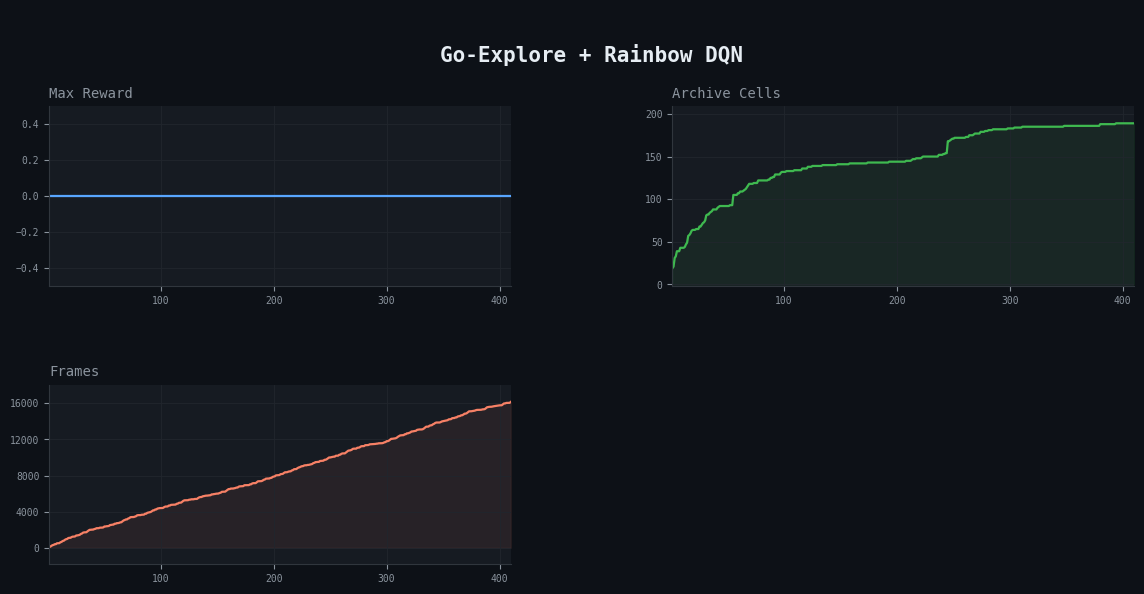

In [ ]:
from collections import defaultdict, deque
import numpy as np
import cv2
import gymnasium as gym
import ale_py
import random
import math
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F

dashboard = MetricsDashboard(
    metrics=['max_reward', 'cells', 'frames'],
    title='Go-Explore + Rainbow DQN', update_every=10,
)

# ──────────────────────────────────────────────
# Go-Explore cell functions (pixel-based)
# ──────────────────────────────────────────────
def cellfn(frame):
    cell = cv2.cvtColor(frame, cv2.COLOR_RGB2GRAY)
    cell = cv2.resize(cell, (11, 8), interpolation=cv2.INTER_AREA)
    cell = cell // 32
    return cell

def hashfn(cell):
    return hash(cell.tobytes())

# ──────────────────────────────────────────────
# Go-Explore archive
# ──────────────────────────────────────────────
e1 = 0.001
e2 = 0.00001

class Weights:
    times_chosen           = 0.1
    times_chosen_since_new = 0.0
    times_seen             = 0.3

class Powers:
    times_chosen           = 0.5
    times_chosen_since_new = 0.5
    times_seen             = 0.5

class Cell:
    def __init__(self):
        self.times_chosen           = 0
        self.times_chosen_since_new = 0
        self.times_seen             = 0

    def __setattr__(self, key, value):
        object.__setattr__(self, key, value)
        if key != 'score' and hasattr(self, 'times_seen'):
            self.score = self.cellscore()

    def cntscore(self, a):
        w = getattr(Weights, a)
        p = getattr(Powers, a)
        v = getattr(self, a)
        return w / (v + e1) ** p + e2

    def cellscore(self):
        return (self.cntscore('times_chosen') +
                self.cntscore('times_chosen_since_new') +
                self.cntscore('times_seen') + 1)

    def visit(self):
        self.times_seen += 1
        return self.times_seen == 1

    def choose(self):
        self.times_chosen           += 1
        self.times_chosen_since_new += 1
        return self.ram, self.reward, self.trajectory


# ──────────────────────────────────────────────
# Noisy Linear Layer (Rainbow component 5)
#
# Replaces nn.Linear in the value and advantage streams with a layer
# that has *learnable* per-weight Gaussian noise parameters.
#
# Standard layer:  y = Wx + b
# Noisy layer:     y = (μ_w + σ_w ⊙ ε_w) x + (μ_b + σ_b ⊙ ε_b)
#
# μ (mu):    learned mean weights — equivalent to the standard weight matrix
# σ (sigma): learned noise scale — how much the network wants to explore
# ε (eps):   factorised Gaussian noise, resampled each forward pass
#
# Factorised noise (used here, from the Rainbow paper) reduces the number
# of random draws from O(p*q) to O(p+q) per layer by sampling p input
# noise values and q output noise values and taking their outer product.
# f(x) = sgn(x) * sqrt(|x|) transforms unit normals into the factorised form.
#
# Why this replaces epsilon-greedy:
# - Epsilon-greedy applies the same noise to all actions in all states
# - Noisy nets learn which weights need more uncertainty — exploration is
#   state-dependent and gradually refined during training
# - sigma_init=0.5 is the value recommended in the Rainbow paper
# ──────────────────────────────────────────────
class NoisyLinear(nn.Module):
    def __init__(self, in_features: int, out_features: int, sigma_init: float = 0.5):
        super().__init__()
        self.in_features  = in_features
        self.out_features = out_features

        # Learnable parameters
        self.weight_mu    = nn.Parameter(torch.empty(out_features, in_features))
        self.weight_sigma = nn.Parameter(torch.empty(out_features, in_features))
        self.bias_mu      = nn.Parameter(torch.empty(out_features))
        self.bias_sigma   = nn.Parameter(torch.empty(out_features))

        # Noise buffers — not parameters, resampled each forward pass
        self.register_buffer('weight_eps', torch.empty(out_features, in_features))
        self.register_buffer('bias_eps',   torch.empty(out_features))

        self.sigma_init = sigma_init
        self._initialise()
        self.resample_noise()

    def _initialise(self):
        bound = 1.0 / math.sqrt(self.in_features)
        self.weight_mu.data.uniform_(-bound, bound)
        self.bias_mu.data.uniform_(-bound, bound)
        self.weight_sigma.data.fill_(self.sigma_init / math.sqrt(self.in_features))
        self.bias_sigma.data.fill_(self.sigma_init / math.sqrt(self.out_features))

    @staticmethod
    def _f(x):
        """Factorised noise transform: sgn(x) * sqrt(|x|)."""
        return x.sign() * x.abs().sqrt()

    def resample_noise(self):
        """Draw fresh factorised Gaussian noise. Call once per forward pass."""
        eps_in  = self._f(torch.randn(self.in_features,  device=self.weight_eps.device))
        eps_out = self._f(torch.randn(self.out_features, device=self.weight_eps.device))
        self.weight_eps.copy_(eps_out.unsqueeze(1) * eps_in.unsqueeze(0))
        self.bias_eps.copy_(eps_out)

    def forward(self, x):
        if self.training:
            weight = self.weight_mu + self.weight_sigma * self.weight_eps
            bias   = self.bias_mu   + self.bias_sigma   * self.bias_eps
        else:
            # At evaluation time use the mean weights only (no noise)
            weight = self.weight_mu
            bias   = self.bias_mu
        return F.linear(x, weight, bias)


# ──────────────────────────────────────────────
# Sum-tree (unchanged)
# ──────────────────────────────────────────────
class SumTree:
    def __init__(self, capacity):
        self.capacity = capacity
        self.nodes    = np.zeros(2 * capacity - 1, dtype=np.float64)
        self.data     = [None] * capacity
        self.write    = 0
        self.size     = 0

    def _leaf_index(self, data_index):
        return data_index + self.capacity - 1

    def _propagate(self, tree_index, delta):
        parent = (tree_index - 1) // 2
        self.nodes[parent] += delta
        if parent != 0:
            self._propagate(parent, delta)

    def update(self, data_index, priority):
        tree_index = self._leaf_index(data_index)
        delta = priority - self.nodes[tree_index]
        self.nodes[tree_index] = priority
        self._propagate(tree_index, delta)

    def add(self, priority, transition):
        self.data[self.write] = transition
        self.update(self.write, priority)
        self.write = (self.write + 1) % self.capacity
        self.size  = min(self.size + 1, self.capacity)

    def sample(self, value):
        node = 0
        while node < self.capacity - 1:
            left, right = 2 * node + 1, 2 * node + 2
            if value <= self.nodes[left]:
                node = left
            else:
                value -= self.nodes[left]
                node   = right
        data_index = node - (self.capacity - 1)
        return data_index, self.nodes[node], self.data[data_index]

    @property
    def total(self):
        return float(self.nodes[0])


# ──────────────────────────────────────────────
# Prioritised Replay Buffer (unchanged)
# ──────────────────────────────────────────────
class PrioritisedReplayBuffer:
    def __init__(self, capacity, alpha=0.6, beta_start=0.4,
                 beta_end=1.0, beta_steps=100_000, epsilon_priority=1e-6):
        self.tree             = SumTree(capacity)
        self.capacity         = capacity
        self.alpha            = alpha
        self.beta             = beta_start
        self.beta_start       = beta_start
        self.beta_end         = beta_end
        self.beta_steps       = beta_steps
        self.epsilon_priority = epsilon_priority
        self.steps_done       = 0
        self._max_priority    = 1.0

    def push(self, state, action, reward, next_state, done):
        self.tree.add(self._max_priority ** self.alpha,
                      (state, action, reward, next_state, done))

    def sample(self, batch_size):
        self.steps_done += 1
        self.beta = min(self.beta_end,
                        self.beta_start + self.steps_done *
                        (self.beta_end - self.beta_start) / self.beta_steps)

        indices, transitions, priorities = [], [], []
        segment = self.tree.total / batch_size
        for i in range(batch_size):
            value = random.uniform(segment * i, segment * (i + 1))
            idx, priority, transition = self.tree.sample(value)
            while transition is None:
                value = random.uniform(0, self.tree.total)
                idx, priority, transition = self.tree.sample(value)
            indices.append(idx)
            priorities.append(priority)
            transitions.append(transition)

        probs   = np.clip(np.array(priorities) / self.tree.total, 1e-10, None)
        weights = (1.0 / (self.tree.size * probs)) ** self.beta
        weights /= weights.max()

        states, actions, rewards, next_states, dones = zip(*transitions)
        return (np.array(states), np.array(actions), np.array(rewards),
                np.array(next_states), np.array(dones),
                np.array(indices, dtype=np.int64),
                np.array(weights, dtype=np.float32))

    def update_priorities(self, indices, errors):
        for idx, err in zip(indices, errors):
            priority = (abs(err) + self.epsilon_priority) ** self.alpha
            self.tree.update(idx, priority)
            self._max_priority = max(self._max_priority, priority)

    def __len__(self):
        return self.tree.size


# ──────────────────────────────────────────────
# N-step Return Buffer (Rainbow component 6)
#
# Sits between the environment and the replay buffer.
# Accumulates n consecutive transitions, then pushes a single
# compressed transition into the PER buffer:
#
#   state    = s_t
#   action   = a_t
#   reward   = r_t + γ*r_{t+1} + ... + γ^{n-1}*r_{t+n-1}   (n-step discounted return)
#   next_state = s_{t+n}
#   done     = True if any transition in the window was terminal
#
# Why n-step helps:
# - Single-step TD targets in Montezuma's Revenge are almost always 0
#   (reward is extremely sparse). The network learns nothing useful from
#   0-target updates for hundreds of steps.
# - n-step returns propagate the reward signal n steps back in a single
#   update, dramatically accelerating learning from rare reward events.
# - n=3 is the value used in the original Rainbow paper.
# ──────────────────────────────────────────────
class NStepBuffer:
    def __init__(self, n: int, gamma: float):
        self.n      = n
        self.gamma  = gamma
        self.buffer = deque()   # stores (state, action, reward, next_state, done)

    def push(self, state, action, reward, next_state, done):
        """
        Add a transition. Returns a compressed n-step transition if the
        buffer is full, otherwise returns None.
        """
        self.buffer.append((state, action, reward, next_state, done))

        if done:
            # Flush all remaining transitions early on episode end
            results = []
            while self.buffer:
                results.append(self._compute_transition())
                self.buffer.popleft()
            return results

        if len(self.buffer) < self.n:
            return None

        result = self._compute_transition()
        self.buffer.popleft()
        return [result]

    def _compute_transition(self):
        """Compute the n-step discounted return from the front of the buffer."""
        state, action = self.buffer[0][0], self.buffer[0][1]

        discounted_reward = 0.0
        done = False
        for i, (_, _, r, next_state, d) in enumerate(self.buffer):
            discounted_reward += (self.gamma ** i) * r
            if d:
                done = True
                break   # Don't accumulate past a terminal

        # next_state is the state n steps ahead (or the terminal state)
        final_next_state = next_state
        return (state, action, discounted_reward, final_next_state, done)

    def flush(self):
        """Drain any remaining partial transitions at episode end."""
        results = []
        while self.buffer:
            results.append(self._compute_transition())
            self.buffer.popleft()
        return results


# ──────────────────────────────────────────────
# Rainbow Network
#
# Combines all three architectural changes:
#   - Distributional: output shape (B, n_actions, n_atoms)
#   - Dueling: separate value V(s,z) and advantage A(s,a,z) streams
#   - Noisy: NoisyLinear replaces nn.Linear in both streams
#
# The shared convolutional backbone uses standard nn.Conv2d — noise is
# only applied in the heads where learned exploration is most useful.
# ──────────────────────────────────────────────
class RainbowNet(nn.Module):
    def __init__(self, input_shape, n_actions, n_atoms, v_min, v_max,
                 sigma_init=0.5):
        super().__init__()
        self.n_actions = n_actions
        self.n_atoms   = n_atoms

        support = torch.linspace(v_min, v_max, n_atoms)
        self.register_buffer('support', support)

        self.conv = nn.Sequential(
            nn.Conv2d(input_shape[0], 32, kernel_size=8, stride=4), nn.ReLU(),
            nn.Conv2d(32, 64, kernel_size=4, stride=2),             nn.ReLU(),
            nn.Conv2d(64, 64, kernel_size=3, stride=1),             nn.ReLU(),
        )
        with torch.no_grad():
            feature_size = self.conv(
                torch.zeros(1, *input_shape)
            ).reshape(1, -1).size(1)

        # Value stream: NoisyLinear → scalar distribution V(s,z)
        self.value_stream = nn.Sequential(
            NoisyLinear(feature_size, 512, sigma_init), nn.ReLU(),
            NoisyLinear(512, n_atoms, sigma_init),
        )
        # Advantage stream: NoisyLinear → per-action distributions A(s,a,z)
        self.advantage_stream = nn.Sequential(
            NoisyLinear(feature_size, 512, sigma_init), nn.ReLU(),
            NoisyLinear(512, n_actions * n_atoms, sigma_init),
        )

    def forward(self, x):
        x        = x.float() / 255.
        features = self.conv(x).reshape(x.size(0), -1)
        B        = features.size(0)

        value     = self.value_stream(features).unsqueeze(1)                    # (B, 1, n_atoms)
        advantage = self.advantage_stream(features).view(B, self.n_actions, self.n_atoms)

        logits = value + advantage - advantage.mean(dim=1, keepdim=True)
        return F.softmax(logits, dim=2)   # (B, n_actions, n_atoms)

    def q_values(self, x):
        """Expected Q-values for action selection: Q(s,a) = Σ_z z * p(s,a,z)."""
        return (self(x) * self.support).sum(dim=2)   # (B, n_actions)

    def resample_noise(self):
        """Resample noise in all NoisyLinear layers. Call once per forward pass."""
        for module in self.modules():
            if isinstance(module, NoisyLinear):
                module.resample_noise()


# ──────────────────────────────────────────────
# Categorical projection (unchanged)
# ──────────────────────────────────────────────
def project_distribution(next_probs, rewards, dones, support, gamma, n_atoms, v_min, v_max):
    B  = rewards.size(0)
    dz = (v_max - v_min) / (n_atoms - 1)

    Tz = (rewards + gamma * (1.0 - dones) * support.unsqueeze(0)).clamp(v_min, v_max)
    b  = (Tz - v_min) / dz
    lo = b.floor().long().clamp(0, n_atoms - 1)
    hi = b.ceil().long().clamp(0, n_atoms - 1)

    m      = torch.zeros(B, n_atoms, device=rewards.device)
    offset = torch.arange(B, device=rewards.device).unsqueeze(1) * n_atoms
    m.view(-1).scatter_add_(0, (lo + offset).view(-1), (next_probs * (hi.float() - b)).view(-1))
    m.view(-1).scatter_add_(0, (hi + offset).view(-1), (next_probs * (b - lo.float())).view(-1))
    return m


# ──────────────────────────────────────────────
# Rainbow Agent
# ──────────────────────────────────────────────
class RainbowAgent:
    def __init__(
        self, env,
        # Distributional
        n_atoms              = 51,
        v_min                = 0.0,
        v_max                = 500.0,
        # N-step
        n_step               = 3,
        # Noisy nets
        sigma_init           = 0.5,
        # Replay
        replay_buffer_capacity = 50_000,
        batch_size             = 32,
        gamma                  = 0.99,
        lr                     = 1e-4,
        grad_clip              = 10.0,
        tau                    = 0.005,
        warmup_steps           = 1_000,
        # PER
        per_alpha              = 0.6,
        per_beta_start         = 0.4,
        per_beta_end           = 1.0,
        per_beta_steps         = 100_000,
    ):
        self.env               = env
        self.action_space_size = env.action_space.n
        obs                    = env.observation_space.shape
        self.input_shape       = (obs[2], obs[0], obs[1])

        self.n_atoms  = n_atoms
        self.v_min    = v_min
        self.v_max    = v_max
        self.gamma    = gamma
        self.n_step   = n_step
        self.grad_clip = grad_clip
        self.tau       = tau
        self.warmup_steps = warmup_steps
        self.batch_size   = batch_size

        # n-step gamma: when computing the Bellman target, the next-state
        # value is discounted by γ^n rather than γ (since it's n steps away)
        self.gamma_n = gamma ** n_step

        self.device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
        print(f'Using device: {self.device}')

        self.policy_net = RainbowNet(
            self.input_shape, self.action_space_size,
            n_atoms, v_min, v_max, sigma_init
        ).to(self.device)
        self.target_net = RainbowNet(
            self.input_shape, self.action_space_size,
            n_atoms, v_min, v_max, sigma_init
        ).to(self.device)
        self.target_net.load_state_dict(self.policy_net.state_dict())
        self.target_net.eval()

        self.optimizer  = optim.Adam(self.policy_net.parameters(), lr=lr)
        self.memory     = PrioritisedReplayBuffer(
            capacity   = replay_buffer_capacity,
            alpha      = per_alpha,
            beta_start = per_beta_start,
            beta_end   = per_beta_end,
            beta_steps = per_beta_steps,
        )
        # N-step buffer sits in front of the replay buffer
        self.nstep_buffer = NStepBuffer(n_step, gamma)

    def _preprocess(self, state):
        return torch.from_numpy(state).permute(2, 0, 1).unsqueeze(0).to(self.device)

    def select_action(self, state):
        """
        Greedy action selection using expected Q-values.
        Noise is resampled before each forward pass so exploration
        is driven by the NoisyLinear layers, not an epsilon schedule.
        """
        self.policy_net.resample_noise()
        with torch.no_grad():
            return self.policy_net.q_values(self._preprocess(state)).argmax(1).item()

    def store(self, state, action, reward, next_state, done):
        """
        Push a transition through the n-step buffer first.
        Only complete n-step transitions (or terminal flushes) reach
        the PER replay buffer.
        """
        results = self.nstep_buffer.push(state, action, reward, next_state, done)
        if results:
            for transition in results:
                self.memory.push(*transition)

    def flush_nstep(self):
        """Drain the n-step buffer at episode end without waiting for n steps."""
        for transition in self.nstep_buffer.flush():
            self.memory.push(*transition)

    def optimize_model(self):
        if len(self.memory) < max(self.batch_size, self.warmup_steps):
            return None

        states, actions, rewards, next_states, dones, indices, is_weights = \
            self.memory.sample(self.batch_size)

        states_t      = torch.from_numpy(states).permute(0, 3, 1, 2).to(self.device)
        next_states_t = torch.from_numpy(next_states).permute(0, 3, 1, 2).to(self.device)
        actions_t     = torch.from_numpy(actions).long().to(self.device)
        rewards_t     = torch.from_numpy(rewards).float().unsqueeze(1).to(self.device)
        dones_t       = torch.from_numpy(dones.astype(np.float32)).unsqueeze(1).to(self.device)
        is_weights_t  = torch.from_numpy(is_weights).float().unsqueeze(1).to(self.device)

        # Resample noise ONCE before the forward pass that needs gradients.
        # A second resample_noise() inside torch.no_grad() would modify
        # weight_eps inplace after the autograd graph has already recorded
        # those buffer tensors, triggering "modified by inplace operation".
        # The no_grad block reuses whatever noise is loaded — it doesn't
        # need fresh noise since no gradient flows through it.
        self.policy_net.resample_noise()

        # Current distribution p(s, a) for taken actions
        current_probs_all = self.policy_net(states_t)                              # (B, A, n_atoms)
        current_probs     = current_probs_all[range(self.batch_size), actions_t]   # (B, n_atoms)

        # Double DQN with n-step discount
        with torch.no_grad():
            # No resample_noise() call here — inplace .copy_() on weight_eps
            # after the forward pass above would corrupt the autograd graph.
            next_actions   = self.policy_net.q_values(next_states_t).argmax(1)    # (B,)
            next_probs_all = self.target_net(next_states_t)                        # (B, A, n_atoms)
            next_probs     = next_probs_all[range(self.batch_size), next_actions]  # (B, n_atoms)

            # Use γ^n for n-step bootstrapping
            target_probs = project_distribution(
                next_probs, rewards_t, dones_t,
                self.policy_net.support, self.gamma_n,
                self.n_atoms, self.v_min, self.v_max,
            )

        log_probs    = torch.log(current_probs + 1e-10)
        element_loss = -(target_probs * log_probs).sum(dim=1, keepdim=True)   # (B, 1)
        loss         = (is_weights_t * element_loss).mean()

        self.optimizer.zero_grad()
        loss.backward()
        nn.utils.clip_grad_norm_(self.policy_net.parameters(), self.grad_clip)
        self.optimizer.step()

        self.memory.update_priorities(indices,
                                      element_loss.detach().cpu().numpy().squeeze(1))

        for p_param, t_param in zip(self.policy_net.parameters(),
                                    self.target_net.parameters()):
            t_param.data.copy_(self.tau * p_param.data + (1 - self.tau) * t_param.data)

        return loss.item()


# ──────────────────────────────────────────────
# State restoration
# ──────────────────────────────────────────────
def restore_env(env, ram):
    env.unwrapped.ale.restoreState(ram)
    return env.unwrapped.ale.getScreenRGB()


# ──────────────────────────────────────────────
# Hyperparameters
# ──────────────────────────────────────────────
WARMUP_ITERS    = 50
STEPS_PER_ITER  = 100
EXPLORE_EPSILON = 0.5   # Used only during Go-Explore warmup;
                        # after warmup NoisyNets drive exploration

archive      = defaultdict(lambda: Cell())
highscore    = 0
frames       = 0

env   = gym.make('ALE/MontezumaRevenge-v5', render_mode='rgb_array')
agent = RainbowAgent(env)

state, _      = env.reset()
score         = 0
trajectory    = []
iterations    = 0
restore_cell  = None
current_lives = get_lives(env)

# ──────────────────────────────────────────────
# Main loop
# ──────────────────────────────────────────────
while True:
    found_new_cell = False

    for step in range(STEPS_PER_ITER):
        # During Go-Explore warmup, random actions populate the archive.
        # After warmup, NoisyNets handle all exploration — no epsilon needed.
        if iterations < WARMUP_ITERS or random.random() < EXPLORE_EPSILON:
            action = env.action_space.sample()
        else:
            action = agent.select_action(state)

        next_state, reward, terminal, truncated, _ = env.step(action)

        new_lives = get_lives(env)
        life_lost = new_lives < current_lives
        done      = terminal or truncated or life_lost

        if iterations >= WARMUP_ITERS:
            agent.store(state, action, reward, next_state, done)
            agent.optimize_model()

        score += reward
        trajectory.append(action)
        frames += 1
        current_lives = new_lives

        if score > highscore:
            highscore = score

        if done:
            if iterations >= WARMUP_ITERS:
                agent.flush_nstep()   # drain partial n-step window at episode end
            score         = 0
            trajectory    = []
            state, _      = env.reset()
            current_lives = get_lives(env)
            break
        else:
            cell_repr   = cellfn(next_state)
            cellhash    = hashfn(cell_repr)
            cell        = archive[cellhash]
            first_visit = cell.visit()

            cell_reward = getattr(cell, 'reward',     -1e9)
            cell_traj   = getattr(cell, 'trajectory', [])
            better  = score > cell_reward
            shorter = score == cell_reward and len(trajectory) < len(cell_traj)

            if first_visit or better or shorter:
                cell.ram        = env.unwrapped.ale.cloneState()
                cell.reward     = score
                cell.trajectory = trajectory.copy()
                cell.times_chosen           = 0
                cell.times_chosen_since_new = 0
                found_new_cell = True

            state = next_state

    if found_new_cell and restore_cell is not None:
        restore_cell.times_chosen_since_new = 0

    iterations += 1

    if len(archive) > 0:
        scores      = np.array([c.score for c in archive.values()])
        hashes      = list(archive.keys())
        probs       = scores / scores.sum()
        chosen_hash = np.random.choice(hashes, p=probs)
        restore_cell = archive[chosen_hash]
        ram, score, trajectory = restore_cell.choose()
        state         = restore_env(env, ram)
        current_lives = get_lives(env)
    else:
        state, _      = env.reset()
        score         = 0
        trajectory    = []
        current_lives = get_lives(env)

    dashboard.update(
        iteration=iterations, frames=frames,
        max_reward=highscore, cells=len(archive),
    )